# SFR Fly Mean-Reversion — 2. Ornstein-Uhlenbeck

**Formulation: fitted OU process.** A z-score assumes the window mean is the
equilibrium and says nothing about how fast the series returns to it. An OU fit
gives both: `mu` (the level it reverts to), `kappa` (the speed, hence a
half-life) and `sigma_eq` (the equilibrium dispersion). The S-score
`(x - mu)/sigma_eq` is the Avellaneda-Lee signal.

The point of this notebook is the **half-life honesty rule**: holding periods
are set from measured half-lives rather than swept, and a fly whose fitted
half-life is sub-1-day is fit noise, not a tradeable signal.

It also carries the cost-aware optimal bands. Three bugs were found and fixed
in the shipped `optimal_ou_thresholds` while writing this
(`docs/superpowers/specs/2026-07-29-sfr-fly-meanrev-findings.md`), the material
one being that its first-passage series had `Gamma(k/2)` in the denominator
instead of the numerator — Monte Carlo on the standardised OU measures
`E[tau(-1 -> +1)] = 3.042` against 2.995 for the corrected series and 1.366 for
the shipped one.

In [1]:
CONFIG = dict(
    primary_structure="3m",
    primary_window="liquid16",
    long_window="front8",
    cost_bp=1.5,
    n_packages=100,
    ou_windows=(120, 250, 500),     # rolling OU estimation window, business days
    entry_zs=(1.0, 1.5, 2.0, 2.5),
    exits=("z0", "half", "t10", "t20"),
    directions=("fade", "momentum"),
    max_hold=40,
    lag=1,
    hl_window=250,                  # window for the reported half-life table
)
CONFIG

{'primary_structure': '3m',
 'primary_window': 'liquid16',
 'long_window': 'front8',
 'cost_bp': 1.5,
 'n_packages': 100,
 'ou_windows': (120, 250, 500),
 'entry_zs': (1.0, 1.5, 2.0, 2.5),
 'exits': ('z0', 'half', 't10', 't20'),
 'directions': ('fade', 'momentum'),
 'max_hold': 40,
 'lag': 1,
 'hl_window': 250}

In [2]:
import sys
from pathlib import Path

sys.path.append("../../")
sys.path.append(str(Path.cwd()))

import dataclasses

import numpy as np
import pandas as pd

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from RVUtils.MeanRev import MRConfig, run_backtest
from RVUtils.MeanRev.signals import ou_sscore_signal
from RVUtils.mean_reversion import (
    adf_pvalue, bertram_thresholds, calibrate_ou, expected_passage_time, half_life,
    ou_band_levels, ou_mle, rolling_ar1, rolling_half_life,
)
from sfr_fly_meanrev_common import (
    coverage_report, header_block, league_row, load_lab, regime_block, run_family,
    three_panel_equity,
)

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

BASE = MRConfig(lag=CONFIG["lag"], round_trip_cost_bp=CONFIG["cost_bp"],
                max_hold=CONFIG["max_hold"], n_packages=CONFIG["n_packages"])
lab = load_lab(CONFIG["primary_structure"], CONFIG["primary_window"])
levels = lab["levels"]
print(f"{levels.shape[1]} flies, {levels.shape[0]} sessions")

34 flies, 1150 sessions


## 1. Measured half-lives, per constant-maturity slot

Fitted on the **absolute** series (no roll), then summarised by the CM slot the
fly occupied. Both the OLS AR(1) fit and the exact MLE are reported so the fit
method is a measurement rather than an assumption, along with the ADF p-value:
a half-life is only meaningful if the series is stationary in the first place.

In [3]:
def ou_row(s, name, slot):
    ols, mle = calibrate_ou(s), ou_mle(s)
    kap = ols.get("kappa", np.nan)
    return {"name": name, "slot": slot, "n": len(s),
            "mean_bp": s.mean(), "sd_bp": s.std(),
            "hl_ols": ols["half_life"], "hl_mle": mle["half_life"],
            "phi": ols["phi"], "mu_bp": ols["mu"],
            "sigma_eq": (ols["sigma"] / np.sqrt(2 * kap)
                         if np.isfinite(kap) and kap > 0 else np.nan),
            "adf_p": adf_pvalue(s)}


# (a) the CONSTANT-MATURITY series -- roll-adjusted, one per slot. This is what
#     a desk means by "the SFR456 fly" and what the rules of thumb quote. It
#     splices contracts every quarter, so it is reporting only.
cm_levels = lab["cm_levels"]
cm_hl = pd.DataFrame([ou_row(cm_levels[c].dropna(), c, lab["slot_of_label"][c])
                      for c in cm_levels.columns
                      if cm_levels[c].notna().sum() > 250]).sort_values("slot")
print("CONSTANT-MATURITY series (roll-adjusted; for reporting):")
print(cm_hl.round(3).to_string(index=False))

# (b) the ABSOLUTE series the backtest actually trades. A key's CM slot rolls
#     through its life, so it is summarised by the MEDIAN slot it occupied.
med_slot = lab["cm_slot_at"].median(axis=0)
rows = []
for key in levels.columns:
    s = levels[key].dropna()
    if len(s) < 250:
        continue
    rows.append(ou_row(s, key, med_slot.get(key, np.nan)))
hl = pd.DataFrame(rows)
hl["slot_bucket"] = pd.cut(hl["slot"], [0, 4, 8, 12, 16],
                           labels=["whites 1-4", "reds 5-8", "greens 9-12",
                                   "blues 13-16"])
print("\nABSOLUTE keys (what is backtested), bucketed by median slot over life:")
print(hl.groupby("slot_bucket", observed=True)
      .agg(n_keys=("name", "size"), hl_ols=("hl_ols", "median"),
           hl_mle=("hl_mle", "median"), sd_bp=("sd_bp", "median"),
           sigma_eq=("sigma_eq", "median"), adf_p=("adf_p", "median"),
           frac_stationary=("adf_p", lambda s: (s < 0.10).mean()))
      .round(3).to_string())
print(f"\nsub-1-day half-lives: {int((hl['hl_ols'] < 1).sum())}/{len(hl)} keys "
      f"(fit noise, not signal)")
print(f"half-lives above 250d (not reverting inside the window): "
      f"{int((hl['hl_ols'] > 250).sum())}/{len(hl)}")
per_slot = cm_hl.rename(columns={"name": "cm"})
per_slot["frac_stationary"] = (per_slot["adf_p"] < 0.10).astype(float)

CONSTANT-MATURITY series (roll-adjusted; for reporting):
        name  slot    n  mean_bp  sd_bp  hl_ols  hl_mle   phi  mu_bp  sigma_eq  adf_p
      SFR123     2 1150    8.648 15.710  33.504  33.504 0.980  8.882    15.699  0.034
      SFR234     3 1150    2.271 10.595  52.699  52.699 0.987  2.698    10.660  0.264
      SFR345     4 1150   -0.076  8.447  42.199  42.199 0.984  0.346     8.502  0.076
      SFR456     5 1150   -1.763  6.453  38.879  38.879 0.982 -1.816     6.439  0.020
      SFR567     6 1150   -3.761  5.216  37.615  37.615 0.982 -4.048     5.113  0.047
      SFR678     7 1150   -4.286  4.047  47.242  47.242 0.985 -4.706     3.734  0.240
      SFR789     8 1149   -3.163  3.206  28.497  28.497 0.976 -3.383     3.024  0.003
  SFR-8-9-10     9 1149   -1.694  1.787  11.654  11.654 0.942 -1.709     1.783  0.000
 SFR-9-10-11    10 1149   -0.686  1.160   8.555   8.555 0.922 -0.687     1.161  0.000
SFR-10-11-12    11 1149   -0.469  1.200   6.115   6.115 0.893 -0.473     1.200  0.0


ABSOLUTE keys (what is backtested), bucketed by median slot over life:
             n_keys  hl_ols  hl_mle  sd_bp  sigma_eq  adf_p  frac_stationary
slot_bucket                                                                 
whites 1-4        2  16.328  16.328  8.537     8.754  0.414            0.000
reds 5-8          9  46.065  46.065  5.399     5.311  0.300            0.111
greens 9-12      11  17.795  17.795  1.860     2.081  0.660            0.091
blues 13-16       2   0.966   0.966  0.390     0.390  0.024            1.000

sub-1-day half-lives: 1/24 keys (fit noise, not signal)
half-lives above 250d (not reverting inside the window): 0/24


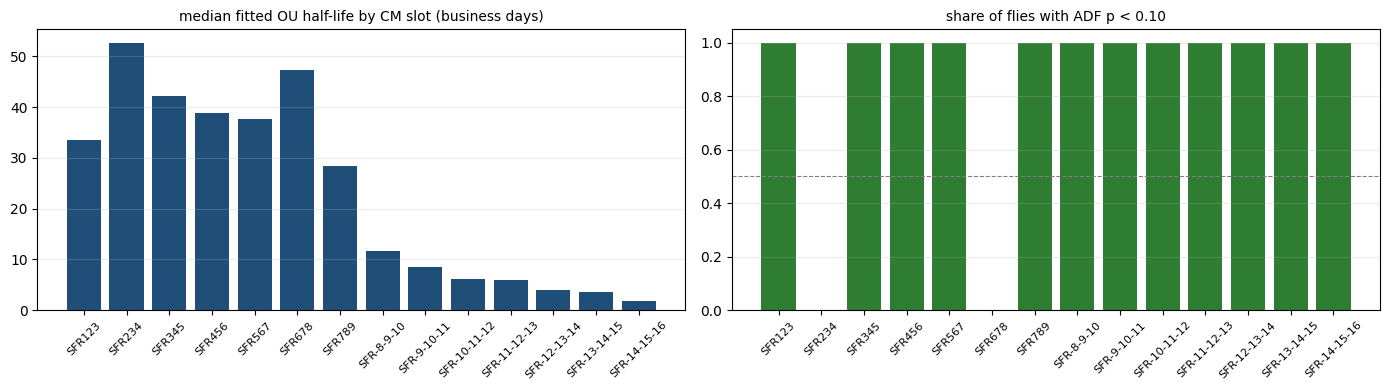

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(per_slot["cm"], per_slot["hl_ols"], color="#1f4e79")
axes[0].set_title("median fitted OU half-life by CM slot (business days)", fontsize=10)
axes[0].tick_params(axis="x", rotation=45, labelsize=8)
axes[0].grid(alpha=0.25, axis="y")
axes[1].bar(per_slot["cm"], per_slot["frac_stationary"], color="#2e7d32")
axes[1].axhline(0.5, color="grey", lw=0.8, ls="--")
axes[1].set_title("share of flies with ADF p < 0.10", fontsize=10)
axes[1].tick_params(axis="x", rotation=45, labelsize=8)
axes[1].grid(alpha=0.25, axis="y")
fig.tight_layout()
plt.show()

## 2. Cost-aware optimal bands

`ou_band_levels` converts the fitted `(mu, kappa, sigma)` and a round-trip cost
into an entry level in **bp**, the expected holding time, and the expected
profit per unit time at that band. A band whose `ret_per_period` is negative
cannot be traded profitably at that cost however it is parameterised — which is
a far stronger statement than any single backtest.

In [5]:
rows = []
for c in cm_levels.columns:
    s = cm_levels[c].dropna()
    if len(s) < 250:
        continue
    p = calibrate_ou(s)
    if not np.isfinite(p.get("kappa", np.nan)) or p["kappa"] <= 0:
        continue
    for cost in (0.0, CONFIG["cost_bp"], 2.5):
        b = ou_band_levels(p, cost=cost)
        rows.append({"cm": c, "slot": lab["slot_of_label"][c], "cost_bp": cost,
                     "mu_bp": p["mu"], "sigma_eq_bp": b["sigma_eq"],
                     "hl_d": p["half_life"],
                     "entry_z": b["entry_z"], "entry_bp": b["entry_level"],
                     "hold_d": b["expected_hold"],
                     "ret_per_day_bp": b["ret_per_period"]})
band_tbl = pd.DataFrame(rows).sort_values(["cost_bp", "slot"])
print("optimal band per CM slot, by cost scenario (bp):")
print(band_tbl.round(3).to_string(index=False))
print("\nNote the shape of the answer: the band the model wants is NARROW "
      "(entry_z well under 1) and the hold it wants is LONG (tens to hundreds "
      "of days). Both are outside the grid a desk would normally sweep.")

optimal band per CM slot, by cost scenario (bp):
          cm  slot  cost_bp  mu_bp  sigma_eq_bp   hl_d  entry_z  entry_bp  hold_d  ret_per_day_bp
      SFR123     2      0.0  8.882       15.699 33.504    0.000     8.882     NaN             NaN
      SFR234     3      0.0  2.698       10.660 52.699    0.000     2.698     NaN             NaN
      SFR345     4      0.0  0.346        8.502 42.199    0.000     0.346     NaN             NaN
      SFR456     5      0.0 -1.816        6.439 38.879    0.000    -1.816     NaN             NaN
      SFR567     6      0.0 -4.048        5.113 37.615    0.000    -4.048     NaN             NaN
      SFR678     7      0.0 -4.706        3.734 47.242    0.000    -4.706     NaN             NaN
      SFR789     8      0.0 -3.383        3.024 28.497    0.000    -3.383     NaN             NaN
  SFR-8-9-10     9      0.0 -1.709        1.783 11.654    0.000    -1.709     NaN             NaN
 SFR-9-10-11    10      0.0 -0.687        1.161  8.555    0.000    -0

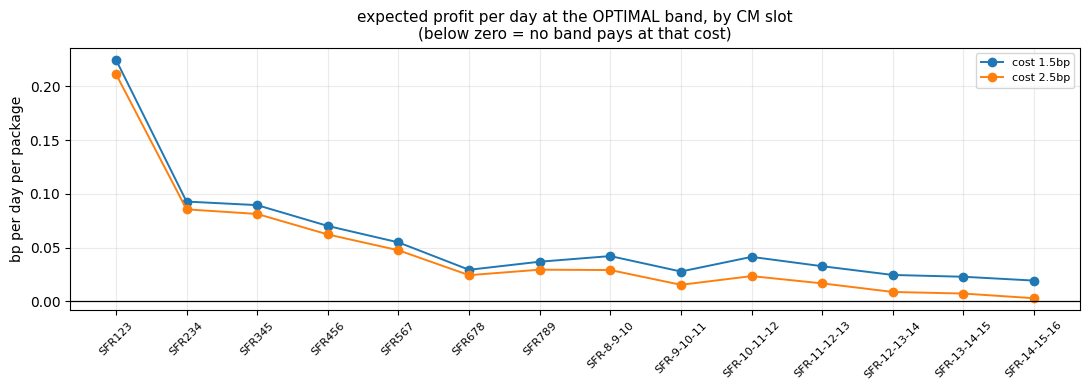

In [6]:
piv = band_tbl.pivot_table(index="cm", columns="cost_bp", values="ret_per_day_bp")
order = band_tbl.drop_duplicates("cm").set_index("cm")["slot"].sort_values().index
piv = piv.reindex(order)
fig, ax = plt.subplots(figsize=(11, 4))
for c in piv.columns:
    ax.plot(piv.index, piv[c], marker="o", lw=1.4, label=f"cost {c}bp")
ax.axhline(0, color="black", lw=0.9)
ax.set_title("expected profit per day at the OPTIMAL band, by CM slot\n"
             "(below zero = no band pays at that cost)", fontsize=11)
ax.set_ylabel("bp per day per package")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 2b. Is the fitted reversion actually regime drift?

A full-sample OU fit assumes one equilibrium `mu` for six years. The panel
audit already showed `SFR123` with a median of **+29bp in HIKING and −2.5bp in
CUTTING**, so a single `mu` is an average of incompatible regimes and the slow
"reversion" it measures may just be the walk between them.

The test: refit inside each regime. If within-regime half-lives collapse and
the `mu`s are far apart, the full-sample fit was measuring regime change.

In [7]:
reg = lab["regimes"]
rows = []
for c in cm_levels.columns:
    full = calibrate_ou(cm_levels[c].dropna())
    rec = {"cm": c, "slot": lab["slot_of_label"][c],
           "hl_full": full["half_life"], "mu_full": full["mu"]}
    mus = []
    for rname in ["ZIRP", "HIKING", "PLATEAU", "CUTTING"]:
        s = cm_levels[c][reg.reindex(cm_levels.index) == rname].dropna()
        if len(s) < 120:
            rec[f"hl_{rname}"] = np.nan
            rec[f"mu_{rname}"] = np.nan
            continue
        p = calibrate_ou(s)
        rec[f"hl_{rname}"] = p["half_life"]
        rec[f"mu_{rname}"] = p["mu"]
        if np.isfinite(p["mu"]):
            mus.append(p["mu"])
    rec["mu_spread_bp"] = (max(mus) - min(mus)) if len(mus) > 1 else np.nan
    rows.append(rec)
rg = pd.DataFrame(rows).sort_values("slot")
hl_cols = [c for c in rg.columns if c.startswith("hl_")]
print("OU half-life (business days), full sample vs within regime:")
print(rg[["cm", "slot"] + hl_cols].round(1).to_string(index=False))
print("\nfitted equilibrium mu (bp), full sample vs within regime:")
mu_cols = [c for c in rg.columns if c.startswith("mu_")]
print(rg[["cm"] + mu_cols].round(2).to_string(index=False))
sub = rg[[c for c in hl_cols if c != "hl_full"]].median(axis=1)
print(f"\nmedian half-life: full sample {rg['hl_full'].median():.1f}d vs "
      f"within-regime {sub.median():.1f}d")
print(f"median spread of mu across regimes: {rg['mu_spread_bp'].median():.2f}bp "
      f"(vs a {CONFIG['cost_bp']}bp round trip)")

OU half-life (business days), full sample vs within regime:
          cm  slot  hl_full  hl_ZIRP  hl_HIKING  hl_PLATEAU  hl_CUTTING
      SFR123     2     33.5      NaN        8.4        40.7        13.2
      SFR234     3     52.7      NaN        7.8         NaN        34.4
      SFR345     4     42.2      NaN       22.6       167.7        35.6
      SFR456     5     38.9      NaN       32.2        10.0        31.6
      SFR567     6     37.6      NaN       33.2        12.5        11.8
      SFR678     7     47.2      NaN       31.9        27.2        13.3
      SFR789     8     28.5      NaN       14.4        23.0         8.8
  SFR-8-9-10     9     11.7      NaN        6.1         7.6         3.8
 SFR-9-10-11    10      8.6      NaN        8.7         2.4         1.4
SFR-10-11-12    11      6.1      NaN        8.9         1.9         1.0
SFR-11-12-13    12      5.9      NaN        3.8         1.2         1.9
SFR-12-13-14    13      4.0      NaN        2.4         0.9         1.2
SFR-

## 3. The corrected first-passage series

The band solver rests on `E[tau]` for the standardised OU. The shipped version
had `Gamma(k/2)` in the denominator; Monte Carlo settles it.

In [8]:
mc = {"(-1, +1)": 3.042, "(-0.5, +0.5)": 1.337, "(0, +1)": 2.144, "(-2, +2)": 12.162}
rows = []
for lab_, (a, m) in {"(-1, +1)": (-1.0, 1.0), "(-0.5, +0.5)": (-0.5, 0.5),
                     "(0, +1)": (0.0, 1.0), "(-2, +2)": (-2.0, 2.0)}.items():
    rows.append({"passage": lab_, "monte_carlo": mc[lab_],
                 "series_used": expected_passage_time(a, m, kappa=1.0)})
pt = pd.DataFrame(rows)
pt["error_pct"] = (pt["series_used"] / pt["monte_carlo"] - 1) * 100
print(pt.round(4).to_string(index=False))
print("\n(Monte Carlo run at dt=5e-4 on dz = -z dt + sqrt(2) dW, 40k paths; the "
      "residual is Euler overshoot, which biases MC high.)")

     passage  monte_carlo  series_used  error_pct
    (-1, +1)        3.042       2.9953    -1.5347
(-0.5, +0.5)        1.337       1.3076    -2.2024
     (0, +1)        2.144       2.0934    -2.3598
    (-2, +2)       12.162      11.8536    -2.5357

(Monte Carlo run at dt=5e-4 on dz = -z dt + sqrt(2) dW, 40k paths; the residual is Euler overshoot, which biases MC high.)


## 4. Backtest — rolling OU S-score

`(x - mu_t)/sigma_eq_t` from a trailing OU fit. NaN wherever the window is not
mean-reverting, so the engine simply does not enter on those bars.


### GRID  (34 keys, 1150 sessions, window=liquid16: every strip slot trades every session from 2022)


  25/96 configs


  50/96 configs


  75/96 configs


  96 configs | median -141.62bp | IQR [-325.25, -66.44] | 0% net-positive | best -1.50bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 window  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
    500      2.5         z0  momentum        13     0.538      -0.115         -1.50        -3750.0  -0.097     -26.25
    500      2.5       half  momentum        13     0.538      -0.192         -2.50        -6250.0  -0.145     -27.25
    500      2.0         z0  momentum        17     0.529      -0.353         -6.00       -15000.0  -0.213     -22.00
    500      2.0       half  momentum        18     0.500      -0.833        -15.00       -37500.0  -0.531     -23.75
    500      2.5        t10  momentum        29     0.172      -0.707        -20.50       -51250.0  -1.446     -32.50
    500      2.5        t20  momentum        18     0.278      -1.278        -23.00       -57500.0  -1.353     -38.50
    250      2.

2. OU S-score (3m, liquid16) - best config  |  momentum|z2.5|z0|hold40|lag1|every1|c1.5  |  100 packages ($2,500/bp, 400 contracts)
  rolling OU fit; entry in sigma_eq units
  trades    13   skipped    0   hit 54%   avg -0.115bp   avg hold 36.1d
  total      -1.50bp   $       -3,750   gross +18.00bp
  daily-MTM Sharpe -0.10   maxDD -26.25bp ($-65,625)   worst trade -7.00bp
  t(trade) -0.12   NW t(daily) -0.10   non-overlap SR +0.20   DSR p=0.007 over 96 trials


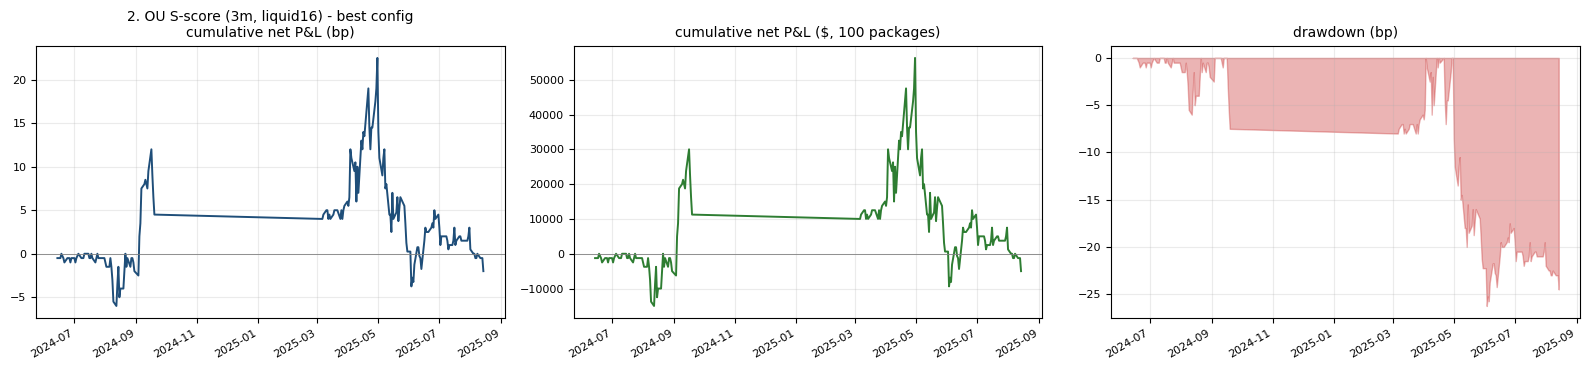


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd    exit_reason
Z25-H26-M26   -1  2024-06-12 2024-06-13 2024-08-12    40 -2.591      -4.0       -3.5      -0.5      1.5    -2.0  -5000.0       max_hold
Z24-H25-M25   -1  2024-08-06 2024-08-07 2024-09-19    30 -2.797     -19.5      -27.5       8.0      1.5     6.5  16250.0 mean_reversion
H26-M26-U26   -1  2025-03-04 2025-03-05 2025-05-01    40 -2.519      -3.5       -8.0       4.5      1.5     3.0   7500.0       max_hold
M26-U26-Z26   -1  2025-03-19 2025-03-20 2025-05-16    40 -3.127      -2.5       -5.5       3.0      1.5     1.5   3750.0       max_hold
Z25-H26-M26   -1  2025-03-19 2025-03-20 2025-05-16    40 -2.890      -5.5       -6.0       0.5      1.5    -1.0  -2500.0       max_hold
U25-Z25-H26   -1  2025-04-01 2025-04-02 2025-05-28    38 -2.608      -6.5       -3.0      -3.5      1.5    -5.0 -12500.0 mean_reversion
U26-Z26-H27   -1  202

exit  n_trades  avg_hold  hit_rate  avg_net_bp  total_net_bp  sharpe
  z0        13    36.077     0.538      -0.115          -1.5  -0.097
half        13    36.000     0.538      -0.192          -2.5  -0.145
band        13    36.000     0.538      -0.192          -2.5  -0.145
  t5        44     4.977     0.068      -1.386         -61.0  -5.368
 t10        29    10.000     0.172      -0.707         -20.5  -1.446
 t20        18    20.000     0.278      -1.278         -23.0  -1.353

  cost curve (round-trip bp charged on the package):
 round_trip_bp  n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 13          18.0       1.385     0.692        45000.0
           0.5 13          11.5       0.885     0.615        28750.0
           1.0 13           5.0       0.385     0.615        12500.0
           1.5 13          -1.5      -0.115     0.538        -3750.0
           2.5 13         -14.5      -1.115     0.385       -36250.0
           4.0 13         -34.0      -2.615     0

2. OU S-score (3m, liquid16) - MEDIAN config (the anti-selection control)  |  fade|z2.5|half|hold40|lag1|every1|c1.5  |  100 packages ($2,500/bp, 400 contracts)
  trades    88   skipped    0   hit 14%   avg -1.605bp   avg hold 17.0d
  total    -141.25bp   $     -353,125   gross -9.25bp
  daily-MTM Sharpe -1.63   maxDD -157.00bp ($-392,500)   worst trade -21.50bp
  t(trade) -4.28   NW t(daily) -3.76   non-overlap SR -0.69   DSR p=0.000 over 96 trials

  LEAGUE ROW  2. OU S-score (3m, liquid16) / best-config: MARGINAL-maker-only  (taker -14.50bp, maker +18.00bp, DSR p=0.007)

  LEAGUE ROW  2. OU S-score (3m, liquid16) / median-config: DEAD  (taker -229.25bp, maker -9.25bp, DSR p=0.000)


In [9]:
GRID = {"window": CONFIG["ou_windows"], "entry_z": CONFIG["entry_zs"],
        "exit_style": CONFIG["exits"], "direction": CONFIG["directions"]}
PARAMS = ["window", "entry_z", "exit_style", "direction"]
SIG = lambda L, window: ou_sscore_signal(L, window=window)      # noqa: E731

out = run_family("2. OU S-score (3m, liquid16)", lab=lab, signal_fn=SIG,
                 grid_spec=GRID, params=PARAMS, base=BASE, cls="ou",
                 note="rolling OU fit; entry in sigma_eq units")

## 4b. Trade the model's OWN recommended band

The band table above says a band exists that pays. The grid above says no
config makes money. Those cannot both be right, so this cell resolves them
directly: for each fly, take the entry threshold and holding period the OU
model itself recommends at 1.5bp, and trade exactly that.

If this loses money while `ret_per_period` is positive, the failure is not the
grid — it is that the fitted `(mu, kappa, sigma)` do not persist out of
sample. That is a much more useful statement than "the sweep was negative".

In [10]:
sig_full = ou_sscore_signal(levels, window=CONFIG["hl_window"])
rows = []
for key in levels.columns:
    s = levels[key].dropna()
    if len(s) < 300:
        continue
    p = calibrate_ou(s)
    if not np.isfinite(p.get("kappa", np.nan)) or p["kappa"] <= 0:
        continue
    b = ou_band_levels(p, cost=CONFIG["cost_bp"])
    if not np.isfinite(b["entry_z"]) or b["entry_z"] <= 0:
        continue
    hold = int(max(2, min(120, round(b["expected_hold"]))))
    cfg = dataclasses.replace(BASE, entry_z=float(b["entry_z"]),
                              exit_style=f"t{hold}", max_hold=hold + 1,
                              direction="fade", keys=[key])
    r = run_backtest(cfg, levels=levels, signal=sig_full, gate=lab["gate"])
    rows.append({"key": key, "entry_z": b["entry_z"], "hold_d": hold,
                 "model_ret_per_day": b["ret_per_period"],
                 "n_trades": r.metrics["n_trades"],
                 "realised_net_bp": r.metrics["total_net_bp"],
                 "realised_gross_bp": r.metrics["total_gross_bp"]})
own = pd.DataFrame(rows)
if not own.empty:
    print(own.round(3).to_string(index=False))
    print(f"\n  model says every band pays "
          f"({int((own['model_ret_per_day'] > 0).sum())}/{len(own)} positive "
          f"ret_per_day); realised net is positive on "
          f"{int((own['realised_net_bp'] > 0).sum())}/{len(own)} keys, "
          f"total {own['realised_net_bp'].sum():+.1f}bp "
          f"(gross {own['realised_gross_bp'].sum():+.1f}bp) over "
          f"{int(own['n_trades'].sum())} trades")

        key  entry_z  hold_d  model_ret_per_day  n_trades  realised_net_bp  realised_gross_bp
H23-M23-U23    0.645      35              0.294         2           -36.25             -33.25
H24-M24-U24    0.711     118              0.071         3            20.00              24.50
H25-M25-U25    0.850     120              0.038         5           -19.75             -12.25
H26-M26-U26    0.932     120              0.025         4           -12.00              -6.00
H27-M27-U27    1.109     116              0.027         3            -1.50               3.00
H28-M28-U28    1.822      41              0.022         0             0.00               0.00
M23-U23-Z23    0.664      49              0.199         3            59.25              63.75
M24-U24-Z24    0.682     120              0.035         3            15.25              19.75
M25-U25-Z25    0.901     120              0.033         5           -15.50              -8.00
M26-U26-Z26    0.903     120              0.023         4   

## 5. Holding period set from the measured half-life, not swept

The honesty rule: if the OU fit is the thesis, the exit should come from the
fit. Each fly is held for `k x its own median half-life`, capped, rather than a
grid-chosen horizon.

In [11]:
hl_map = hl.set_index("name")["hl_ols"]      # ou_row() names the column "name"
rows = []
sig = ou_sscore_signal(levels, window=CONFIG["hl_window"])
for k in (0.5, 1.0, 1.5, 2.0):
    tot_bp, tot_tr, tot_usd = 0.0, 0, 0.0
    for key in levels.columns:
        h = hl_map.get(key, np.nan)
        if not np.isfinite(h) or h < 1 or h > 250:
            continue
        hold = int(max(1, min(60, round(k * h))))
        cfg = dataclasses.replace(BASE, exit_style=f"t{hold}", max_hold=hold + 1,
                                  entry_z=2.0, direction="fade", keys=[key])
        r = run_backtest(cfg, levels=levels, signal=sig, gate=lab["gate"])
        tot_bp += r.metrics["total_net_bp"]
        tot_usd += r.metrics["total_net_usd"]
        tot_tr += r.metrics["n_trades"]
    rows.append({"hold_multiple_of_half_life": k, "n_trades": tot_tr,
                 "total_net_bp": tot_bp, "total_net_usd": tot_usd})
print("holding period = k x each fly's OWN fitted half-life:")
print(pd.DataFrame(rows).round(2).to_string(index=False))

holding period = k x each fly's OWN fitted half-life:
 hold_multiple_of_half_life  n_trades  total_net_bp  total_net_usd
                        0.5        97       -125.50      -313750.0
                        1.0        65       -112.50      -281250.0
                        1.5        59        -76.25      -190625.0
                        2.0        53       -107.75      -269375.0


## 6. Long window and 6m


### GRID  (42 keys, 1907 sessions, window=front8: slots 1-8 are continuously liquid from 2019; buys ZIRP+hiking)


  25/96 configs


  50/96 configs


  75/96 configs


  96 configs | median -53.88bp | IQR [-147.75, +0.00] | 4% net-positive | best +59.25bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 window  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
    250      1.5        t20      fade        47     0.426       1.261         59.25       148125.0   0.630     -37.25
    250      2.5        t20      fade        21     0.429       2.000         42.00       105000.0   0.792     -32.50
    250      2.0        t20      fade        31     0.419       1.040         32.25        80625.0   0.496     -28.50
    250      1.0        t20      fade        85     0.282       0.279         23.75        59375.0   0.170     -55.00
    500      1.0         z0      fade         0       NaN         NaN          0.00            0.0     NaN       0.00
    500      1.0         z0  momentum         0       NaN         NaN          0.00            0.0     NaN       0.00
    500      1.0

2b. OU S-score (3m, front8, 2019+) - best config  |  fade|z1.5|t20|hold40|lag1|every1|c1.5  |  100 packages ($2,500/bp, 400 contracts)
  long history including ZIRP and the hiking cycle
  trades    47   skipped    0   hit 43%   avg +1.261bp   avg hold 18.5d
  total     +59.25bp   $     +148,125   gross +129.75bp
  daily-MTM Sharpe +0.63   maxDD -37.25bp ($-93,125)   worst trade -18.00bp
  t(trade) +0.96   NW t(daily) +1.09   non-overlap SR +0.23   DSR p=0.038 over 96 trials


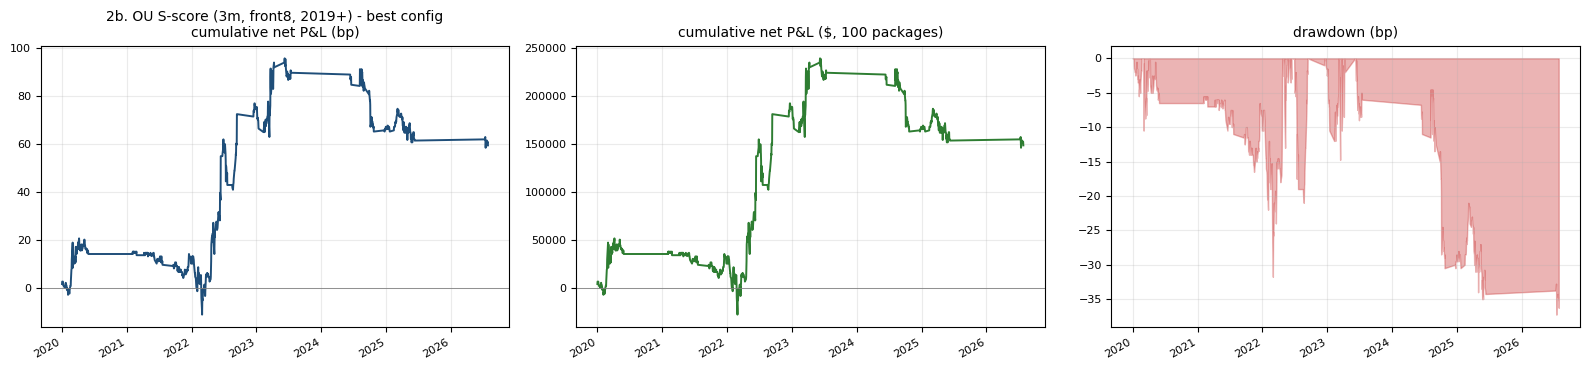


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd exit_reason
H20-M20-U20   -1  2019-12-30 2019-12-31 2020-01-30    20  2.133      2.50       2.00      0.50      1.5   -1.00  -2500.0        time
M20-U20-Z20   -1  2020-01-21 2020-01-22 2020-02-20    20  1.542     -1.50       0.00     -1.50      1.5   -3.00  -7500.0        time
H20-M20-U20   -1  2020-02-04 2020-02-05 2020-03-05    20  1.636      1.50     -16.50     18.00      1.5   16.50  41250.0        time
M20-U20-Z20   -1  2020-02-21 2020-02-24 2020-03-23    20  1.552      0.00      -4.50      4.50      1.5    3.00   7500.0        time
H20-M20-U20    1  2020-03-12 2020-03-13 2020-03-17     2 -1.642    -12.50     -10.00      2.50      1.5    1.00   2500.0        time
U20-Z20-H21   -1  2020-03-17 2020-03-18 2020-04-16    20  2.062     -0.00      -0.00     -0.00      1.5   -1.50  -3750.0        time
M20-U20-Z20    1  2020-03-24 2020-03-25 20


LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            1.5        47           129.8          59.2       1.261     0.426   0.630      -37.3      18.5          False             False
         belly       1            0.5        47           435.0         411.5       8.755     0.532   1.238     -119.0      18.5           True              True
belly_vs_front       2            1.0        47           120.8          73.8       1.569     0.489   0.614      -60.2      18.5           True             False
 belly_vs_back       2            1.0        47             9.0         -38.0      -0.809     0.426  -0.448      -78.0      18.5          False             False
  -> SHADOWED - a simpler instrument beats the fly on net bp


2b. OU S-score (3m, front8, 2019+) - MEDIAN config (the anti-selection control)  |  fade|z1.5|half|hold40|lag1|every1|c1.5  |  100 packages ($2,500/bp, 400 contracts)
  trades    48   skipped    0   hit 33%   avg -1.099bp   avg hold 17.6d
  total     -52.75bp   $     -131,875   gross +19.25bp
  daily-MTM Sharpe -0.49   maxDD -66.00bp ($-165,000)   worst trade -23.50bp
  t(trade) -1.06   NW t(daily) -0.92   non-overlap SR -0.16   DSR p=0.000 over 96 trials

  LEAGUE ROW  2b. OU S-score (3m, front8, 2019+) / best-config: SELECTION-ARTIFACT  (taker +12.25bp, maker +129.75bp, DSR p=0.038)

  LEAGUE ROW  2b. OU S-score (3m, front8, 2019+) / median-config: MARGINAL-maker-only  (taker -100.75bp, maker +19.25bp, DSR p=0.000)


In [12]:
lab8 = load_lab(CONFIG["primary_structure"], CONFIG["long_window"])
out8 = run_family("2b. OU S-score (3m, front8, 2019+)", lab=lab8, signal_fn=SIG,
                  grid_spec=GRID, params=PARAMS, base=BASE, cls="ou",
                  note="long history including ZIRP and the hiking cycle")


### GRID  (32 keys, 1150 sessions, window=liquid16: every strip slot trades every session from 2022)


  25/96 configs


  50/96 configs


  75/96 configs


  96 configs | median -87.88bp | IQR [-304.19, +19.31] | 30% net-positive | best +145.00bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 window  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
    120      2.0       half  momentum       140     0.379       1.036        145.00       362500.0   0.471     -69.50
    120      2.5       half  momentum        86     0.453       1.375        118.25       295625.0   0.466     -78.50
    120      2.0        t20  momentum       135     0.333       0.820        110.75       276875.0   0.292    -115.50
    250      2.0         z0  momentum        47     0.532       2.229        104.75       261875.0   0.467     -82.00
    120      2.5         z0  momentum        84     0.464       1.164         97.75       244375.0   0.329    -108.25
    250      1.5         z0  momentum        77     0.481       1.247         96.00       240000.0   0.369    -126.50
    120      

2c. OU S-score (6m, liquid16) - best config  |  momentum|z2.0|half|hold40|lag1|every1|c1.5  |  100 packages ($2,500/bp, 400 contracts)
  6m flies
  trades   140   skipped    1   hit 38%   avg +1.036bp   avg hold 15.9d
  total    +145.00bp   $     +362,500   gross +355.00bp
  daily-MTM Sharpe +0.47   maxDD -69.50bp ($-173,750)   worst trade -34.50bp
  t(trade) +0.95   NW t(daily) +0.75   non-overlap SR -0.11   DSR p=0.000 over 96 trials


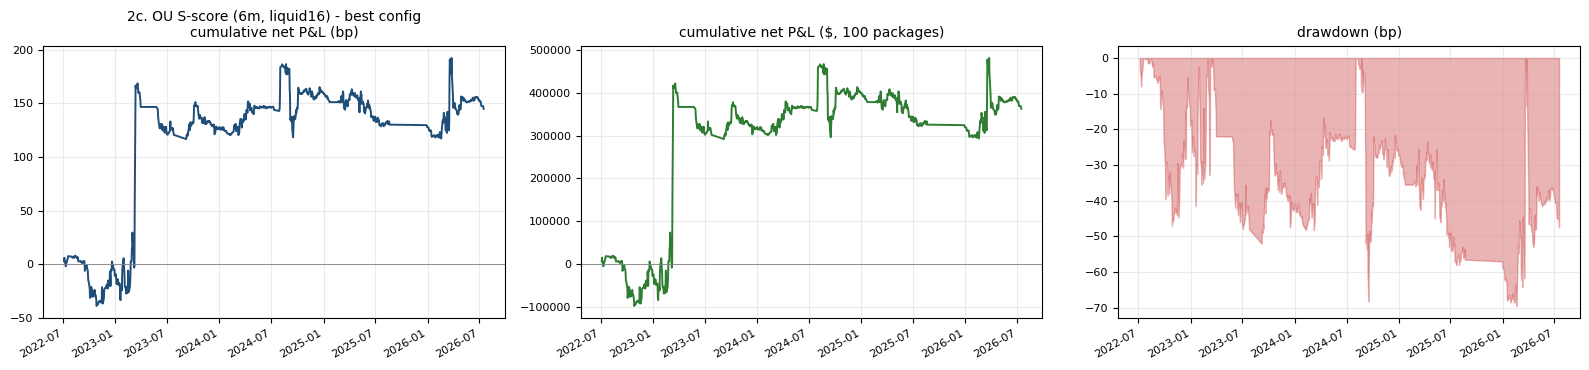


  trade log (first rows):
        key  dir signal_date      entry       exit  days    z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd exit_reason
M23-Z23-M24    1  2022-06-30 2022-07-01 2022-07-07     3   2.864    -18.00     -14.50      3.50      1.5    2.00   5000.0 take_profit
H23-U23-H24    1  2022-07-06 2022-07-07 2022-07-11     2   2.305     -5.00      -7.50     -2.50      1.5   -4.00 -10000.0 take_profit
M23-Z23-M24    1  2022-07-08 2022-07-11 2022-07-13     2   2.156    -13.50      -9.00      4.50      1.5    3.00   7500.0 take_profit
H23-U23-H24    1  2022-07-12 2022-07-13 2022-07-19     4   3.349    -11.00      -3.00      8.00      1.5    6.50  16250.0 take_profit
Z24-M25-Z25   -1  2022-08-01 2022-08-02 2022-08-24    16  -2.365     -9.50      -6.00     -3.50      1.5   -5.00 -12500.0 take_profit
Z23-M24-Z24   -1  2022-08-29 2022-08-30 2022-09-28    20  -2.016    -17.50     -15.00     -2.50      1.5   -4.00 -10000.0 take_profit
U23-H24-U24   -1  2022-09-13 2022-0

exit  n_trades  avg_hold  hit_rate  avg_net_bp  total_net_bp  sharpe
  z0       134    21.851     0.410       0.146         19.50   0.058
half       140    15.900     0.379       1.036        145.00   0.471
band       140    15.900     0.379       1.036        145.00   0.471
  t5       223     4.960     0.229      -0.355        -79.25  -0.322
 t10       174     9.897     0.253      -0.786       -136.75  -0.656
 t20       135    19.674     0.333       0.820        110.75   0.292

  cost curve (round-trip bp charged on the package):
 round_trip_bp   n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 140         355.0       2.536     0.450       887500.0
           0.5 140         285.0       2.036     0.414       712500.0
           1.0 140         215.0       1.536     0.379       537500.0
           1.5 140         145.0       1.036     0.379       362500.0
           2.5 140           5.0       0.036     0.343        12500.0
           4.0 140        -205.0      -1.46


LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            1.5       140           355.0         145.0       1.036     0.379   0.471      -69.5      15.9          False             False
         belly       1            0.5       140           400.0         330.0       2.357     0.493   0.365     -459.5      15.9           True             False
belly_vs_front       2            1.0       140           299.5         159.5       1.139     0.400   0.582     -101.3      15.9           True              True
 belly_vs_back       2            1.0       140            55.5         -84.5      -0.604     0.407  -0.429     -159.5      15.9          False             False
  -> SHADOWED - a simpler instrument beats the fly on net bp


2c. OU S-score (6m, liquid16) - MEDIAN config (the anti-selection control)  |  fade|z1.5|t20|hold40|lag1|every1|c1.5  |  100 packages ($2,500/bp, 400 contracts)
  trades    23   skipped    0   hit 30%   avg -3.837bp   avg hold 18.1d
  total     -88.25bp   $     -220,625   gross -53.75bp
  daily-MTM Sharpe -1.39   maxDD -140.00bp ($-350,000)   worst trade -29.00bp
  t(trade) -1.67   NW t(daily) -1.50   non-overlap SR -0.27   DSR p=0.000 over 96 trials

  LEAGUE ROW  2c. OU S-score (6m, liquid16) / best-config: SELECTION-ARTIFACT  (taker +5.00bp, maker +355.00bp, DSR p=0.000)

  LEAGUE ROW  2c. OU S-score (6m, liquid16) / median-config: DEAD  (taker -111.25bp, maker -53.75bp, DSR p=0.000)


In [13]:
lab6 = load_lab("6m", CONFIG["primary_window"])
out6 = run_family("2c. OU S-score (6m, liquid16)", lab=lab6, signal_fn=SIG,
                  grid_spec=GRID, params=PARAMS, base=BASE, cls="ou",
                  note="6m flies")

## 7. Rolling half-life stability

A half-life is only usable if it is stable. This plots the rolling estimate for
the front and back of the strip.

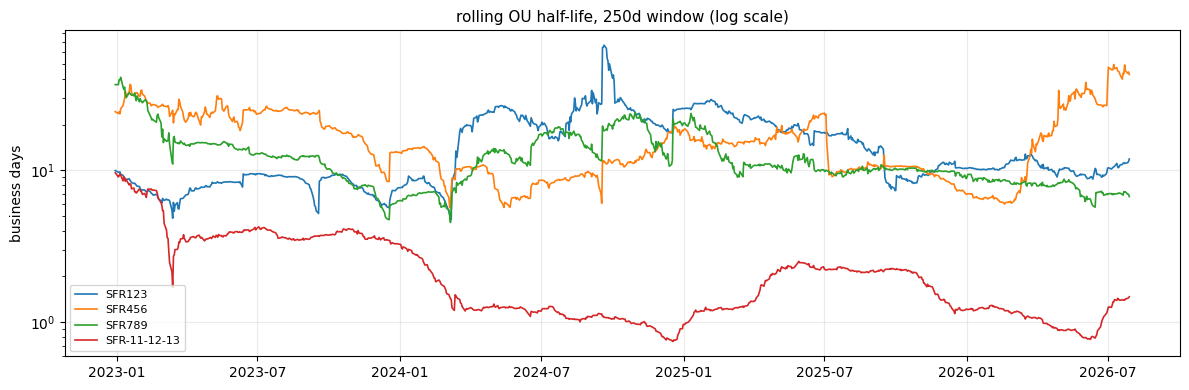

In [14]:
pick = [c for c in cm_levels.columns
        if lab["slot_of_label"][c] in (2, 5, 8, 12)]
fig, ax = plt.subplots(figsize=(12, 4))
for c in pick:
    rh = rolling_half_life(cm_levels[c].dropna(), CONFIG["hl_window"])
    ax.plot(rh.index, rh.to_numpy(), lw=1.2, label=c)
ax.set_yscale("log")
ax.set_title(f"rolling OU half-life, {CONFIG['hl_window']}d window (log scale)",
             fontsize=11)
ax.set_ylabel("business days")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()